# ML Basket 1: Economic Classification (Offensive vs Defensive)

## Overview
This Jupyter Notebook constructs ML-ready portfolios by classifying factors into Offensive (growth/expansion) and Defensive (quality/safety) categories. It selects long-only legs (P1 or P10), computes equal-weighted returns and turnovers, and generates aggregated baskets for machine learning applications.

## Key Features
- **Factor Classification**: Offensive (9 factors: growth, efficiency) vs Defensive (16 factors: profitability, liquidity, quality).
- **Leg Selection**: Automated P1/P10 choice based on economic logic (e.g., buy high growth, low leverage).
- **Portfolio Construction**: Equal-weighted aggregation of factor portfolios.
- **Turnover Calculation**: Aggregated monthly turnovers for transaction cost analysis.
- **Visualization**: Cumulative returns plots with CAGR stats.

## Methodology
1. Define Offensive and Defensive factor configurations with leg selections.
2. Load signal Parquet files and extract relevant returns/turnovers.
3. Aggregate into Offensive and Defensive portfolios (EW).
4. Compute and aggregate turnovers.
5. Save aggregated baskets and individual returns; generate plots.

## Dependencies
- Libraries: pandas, numpy, matplotlib, pathlib.
- Data: Signal Parquet files from data/portfolios/.
- Environment: macOS with VS Code, Python 3.x.

## Usage
1. Adjust OFFENSIVE_CONFIG and DEFENSIVE_CONFIG if needed.
2. Run cells to load data, compute portfolios, and save outputs.
3. Review saved Parquet files and cumulative returns plots.

## Output Files
- **data/ml_data/baskets/basket_1_economic_classification.parquet**: Parquet with Market, Offensive, Defensive returns, and aggregated turnovers.
- **data/ml_data/features/baseline/basket_1_individual_returns_50.parquet**: Parquet with 50 individual portfolio returns (25 factors × P10 and P1).

This notebook prepares economic-based baskets for ML modeling, ensuring factor diversity and academic rigor.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
print("="*100)
print("🎯 CONFIGURATION : SÉLECTION DES BEST LEGS (P1 ou P10)")
print("="*100)

# ═══════════════════════════════════════════════════════════════════════════
# PANIERS LONG-ONLY : SÉLECTION DES LEGS INVESTISSABLES
# ═══════════════════════════════════════════════════════════════════════════

OFFENSIVE_CONFIG = {
    # CROISSANCE & EXPANSION
    'sales_growth': 'P10',              # Buy High Sales Growth (expansion)
    'asset_growth': 'P10',              # Buy Empire Builders (growth)
    'investment_capex': 'P10',          # Buy High CapEx (aggressive investment)
    'capex_growth': 'P10',              # Buy CapEx Acceleration
    
    # VITESSE & EFFICACITÉ AGRESSIVE
    'asset_turnover': 'P10',            # Buy High Asset Turnover (revenue velocity)
    'change_asset_turnover': 'P10',     # Buy Improving Turnover
    'receivables_turnover': 'P10',      # Buy Fast Collection
    'cash_productivity': 'P10',         # Buy High Cash Velocity
    'operating_leverage': 'P10',        # Buy Operating Leverage
}


DEFENSIVE_CONFIG = {
    # PROFITABILITÉ (Quality)
    'gross_profitability': 'P10',       # Buy High Margins
    'operating_profitability': 'P10',   # Buy Strong Operations
    'return_on_assets': 'P10',          # Buy High ROA
    'roic': 'P10',                      # Buy High Return on Invested Capital
    'change_profit_margin': 'P10',      # Buy Margin Improvement
    
    # LIQUIDITÉ & SOLVABILITÉ (Safety)
    'cash_cushion': 'P10',              # Buy High Cash Buffer
    'debt_capacity': 'P10',             # Buy High Debt Capacity (tangible assets)
    'change_current_ratio': 'P10',      # Buy Improving Liquidity
    
    # QUALITÉ (Low Accruals = Good)
    'working_capital_accruals': 'P1',   # Buy LOW Accruals (P1 = conservative)
    'sales_receivables_gap': 'P10',     # Buy Real Demand
    'net_share_issues': 'P1',           # Buy LOW Dilution
    
    # CONSERVATISME
    'book_leverage': 'P1',              # Buy LOW Leverage (safe)
    'depreciation_to_ppe': 'P1',        # Buy LOW Depreciation (young assets)
    'change_depreciation': 'P1',        # Buy LOW Δ Depreciation
    
    # EFFICIENCY (conservative)
    'tax_income_ratio': 'P10',          # Buy Tax Efficiency
    'capex_inventory_growth': 'P1',     # Buy LOW Combined Growth (disciplined)
}




print(f"\n✅ Configuration définie :")
print(f"   • Panier OFFENSIF  : {len(OFFENSIVE_CONFIG)} facteurs")
print(f"   • Panier DÉFENSIF  : {len(DEFENSIVE_CONFIG)} facteurs")

print(f"\n📊 Détails Offensif :")
for factor, leg in OFFENSIVE_CONFIG.items():
    print(f"   • {factor:<30} → {leg}")

print(f"\n📊 Détails Défensif :")
for factor, leg in DEFENSIVE_CONFIG.items():
    print(f"   • {factor:<30} → {leg}")

print("\n" + "="*100)

🎯 CONFIGURATION : SÉLECTION DES BEST LEGS (P1 ou P10)

✅ Configuration définie :
   • Panier OFFENSIF  : 9 facteurs
   • Panier DÉFENSIF  : 16 facteurs

📊 Détails Offensif :
   • sales_growth                   → P10
   • asset_growth                   → P10
   • investment_capex               → P10
   • capex_growth                   → P10
   • asset_turnover                 → P10
   • change_asset_turnover          → P10
   • receivables_turnover           → P10
   • cash_productivity              → P10
   • operating_leverage             → P10

📊 Détails Défensif :
   • gross_profitability            → P10
   • operating_profitability        → P10
   • return_on_assets               → P10
   • roic                           → P10
   • change_profit_margin           → P10
   • cash_cushion                   → P10
   • debt_capacity                  → P10
   • change_current_ratio           → P10
   • working_capital_accruals       → P1
   • sales_receivables_gap          → P10
   • ne

In [3]:
print("="*100)
print("📦 CONSTRUCTION DES PORTFOLIOS DEPUIS LES SIGNAUX")
print("="*100)

# ═══════════════════════════════════════════════════════════════════════════
# 1. CHARGER TOUS LES SIGNAUX ET CONSTRUIRE LES PORTFOLIOS
# ═══════════════════════════════════════════════════════════════════════════

# Initialiser les DataFrames pour stocker les returns
offensive_returns = []
defensive_returns = []
market_return = None

# OFFENSIVE
for factor, leg in OFFENSIVE_CONFIG.items():
    signal_path = Path(f'data/portfolios/{factor}_signal.parquet')
    
    if signal_path.exists():
        signal_df = pd.read_parquet(signal_path).set_index('date')
        
        # Sélectionner le bon leg
        if leg == 'P10':
            offensive_returns.append(signal_df['ret_high_ew'])
        else:  # P90
            offensive_returns.append(signal_df['ret_low_ew'])
        
        # Charger Market (une seule fois)
        if market_return is None:
            market_return = signal_df['ret_high_ew'] * 0  # Structure vide
            # On utilisera le market d'un fichier spécifique après

# DEFENSIVE
for factor, leg in DEFENSIVE_CONFIG.items():
    signal_path = Path(f'data/portfolios/{factor}_signal.parquet')
    
    if signal_path.exists():
        signal_df = pd.read_parquet(signal_path).set_index('date')
        
        # Sélectionner le bon leg
        if leg == 'P10':
            defensive_returns.append(signal_df['ret_high_ew'])
        else:  # P90
            defensive_returns.append(signal_df['ret_low_ew'])

# Construire les portfolios Equal-Weighted
Portfolio_Expansion = pd.concat(offensive_returns, axis=1).mean(axis=1)
Portfolio_Contraction = pd.concat(defensive_returns, axis=1).mean(axis=1)

# Charger le Market depuis earnings_accel (arbitraire, juste besoin d'un benchmark)
market_df = pd.read_parquet('data/portfolios/cash_cushion_signal.parquet').set_index('date')

# Utiliser ret_high_ew comme proxy du market (ou créer Market = moyenne de tous les high)
# Option : Utiliser le VW market si disponible
df_p10 = pd.DataFrame({'Market': market_df['ret_high_ew']})

print(f"✅ Portfolio Offensive  : {len(Portfolio_Expansion)} mois")
print(f"✅ Portfolio Defensive  : {len(Portfolio_Contraction)} mois")
print(f"✅ Market loaded        : {len(df_p10)} mois")
print("="*100)

📦 CONSTRUCTION DES PORTFOLIOS DEPUIS LES SIGNAUX
✅ Portfolio Offensive  : 738 mois
✅ Portfolio Defensive  : 738 mois
✅ Market loaded        : 738 mois


In [4]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 5.5 : CHARGER LES TURNOVERS
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("📦 CHARGEMENT DES TURNOVERS")
print("="*100)

# Construire dict des turnovers (même logique que les returns)
all_factors = {**OFFENSIVE_CONFIG, **DEFENSIVE_CONFIG}
turnover_dict = {}

for factor in set(all_factors.keys()):
    signal_path = Path(f'data/portfolios/{factor}_signal.parquet')
    if signal_path.exists():
        signal_df = pd.read_parquet(signal_path).set_index('date')
        turnover_dict[f'{factor}_turnover_high'] = signal_df['turnover_high_ew']
        turnover_dict[f'{factor}_turnover_low'] = signal_df['turnover_low_ew']

df_turnover = pd.DataFrame(turnover_dict)

print(f"✅ Turnovers loaded : {df_turnover.shape}")
print("="*100)

📦 CHARGEMENT DES TURNOVERS
✅ Turnovers loaded : (738, 50)


In [5]:
print("="*100)
print("📦 CELL 6 : CALCUL TURNOVER & PRÉPARATION OUTPUT")
print("="*100)

# ═══════════════════════════════════════════════════════════════════════════
# 1. CALCULER TURNOVER AGRÉGÉ (EQUAL-WEIGHTED)
# ═══════════════════════════════════════════════════════════════════════════

def compute_portfolio_turnover(config, df_turnover):
    """
    Calcule le turnover agrégé d'un portfolio Equal-Weighted.
    
    Parameters:
    -----------
    config : dict
        Ex: {'earnings_accel': 'P10', 'sales_accel': 'P10', ...}
    df_turnover : DataFrame
        Contient les colonnes {factor}_turnover_high et {factor}_turnover_low
    
    Returns:
    --------
    pd.Series : Turnover agrégé mensuel (Equal-Weighted)
    """
    turnover_series = []
    
    for factor, leg in config.items():
        # ═══════════════════════════════════════════════════════════════════
        # MAPPING CORRECT : {factor}_turnover_high ou {factor}_turnover_low
        # ═══════════════════════════════════════════════════════════════════
        
        if leg == 'P10':
            col_name = f'{factor}_turnover_high'  # P10 = High decile
        else:  # leg == 'P90'
            col_name = f'{factor}_turnover_low'   # P90 = Low decile
        
        if col_name in df_turnover.columns:
            turnover_series.append(df_turnover[col_name])
        else:
            print(f"⚠️  Colonne manquante : {col_name}")
            # Debug : afficher les colonnes disponibles
            matching = [c for c in df_turnover.columns if factor in c and 'turnover' in c]
            if matching:
                print(f"   Colonnes disponibles : {matching}")
    
    if not turnover_series:
        print("⚠️  Aucune série de turnover trouvée ! Retour série nulle.")
        return pd.Series(0, index=df_turnover.index)
    
    # Moyenne Equal-Weighted
    return pd.concat(turnover_series, axis=1).mean(axis=1)

# ═══════════════════════════════════════════════════════════════════════════
# 2. CALCULER LES TURNOVERS
# ═══════════════════════════════════════════════════════════════════════════

print("\n🔄 Calcul du turnover agrégé...\n")

Turnover_Offensive = compute_portfolio_turnover(OFFENSIVE_CONFIG, df_turnover)
Turnover_Defensive = compute_portfolio_turnover(DEFENSIVE_CONFIG, df_turnover)

print(f"\n✅ Turnover Offensive (moyenne) :")
print(f"   • Mensuel     : {Turnover_Offensive.mean()*100:.2f}%")
print(f"   • Annualisé   : {Turnover_Offensive.mean()*1200:.1f}%")

print(f"\n✅ Turnover Defensive (moyenne) :")
print(f"   • Mensuel     : {Turnover_Defensive.mean()*100:.2f}%")
print(f"   • Annualisé   : {Turnover_Defensive.mean()*1200:.1f}%")

# ═══════════════════════════════════════════════════════════════════════════
# 3. CRÉER LE DATAFRAME FINAL
# ═══════════════════════════════════════════════════════════════════════════

df_output = pd.DataFrame({
    'Market': df_p10['Market'],
    'Offensive': Portfolio_Expansion,
    'Defensive': Portfolio_Contraction,
    'Turnover_Off': Turnover_Offensive,
    'Turnover_Def': Turnover_Defensive
})

print(f"\n✅ DataFrame output créé :")
print(f"   • Shape        : {df_output.shape}")
print(f"   • Period       : {df_output.index.min().date()} → {df_output.index.max().date()}")
print(f"   • Missing vals : {df_output.isnull().sum().sum()}")

print(f"\n📊 Aperçu :")
print(df_output.head(10))

# ═══════════════════════════════════════════════════════════════════════════
# 4. STATS DESCRIPTIVES RAPIDES
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "-"*100)
print("📊 STATS DESCRIPTIVES (Returns)")
print("-"*100)

stats = df_output[['Market', 'Offensive', 'Defensive']].describe()
print(stats.round(4).to_string())

print("\n" + "-"*100)
print("📊 STATS DESCRIPTIVES (Turnover)")
print("-"*100)

turnover_stats = df_output[['Turnover_Off', 'Turnover_Def']].describe()
print(turnover_stats.round(4).to_string())

# # ═══════════════════════════════════════════════════════════════════════════
# # 5. SAUVEGARDER
# # ═══════════════════════════════════════════════════════════════════════════

OUTPUT_PATH = Path('data/ml_data/baskets/basket_1_economic_classification.parquet')
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

df_output.to_parquet(OUTPUT_PATH)

print(f"\n✅ SAUVEGARDE TERMINÉE :")
print(f"   📁 {OUTPUT_PATH}")
print(f"   📦 Contenu : 5 colonnes")
print(f"      • Market        : Return marché")
print(f"      • Offensive     : Return portfolio Offensive (9 facteurs)")
print(f"      • Defensive     : Return portfolio Defensive (16 facteurs)")
print(f"      • Turnover_Off  : Turnover agrégé Offensive")
print(f"      • Turnover_Def  : Turnover agrégé Defensive")

print("\n" + "="*100)
print("✅ PROCHAINE ÉTAPE : Analyse FF6 / Regime-Switching / Transaction Costs")
print("="*100)

📦 CELL 6 : CALCUL TURNOVER & PRÉPARATION OUTPUT

🔄 Calcul du turnover agrégé...


✅ Turnover Offensive (moyenne) :
   • Mensuel     : 80.90%
   • Annualisé   : 970.8%

✅ Turnover Defensive (moyenne) :
   • Mensuel     : 77.07%
   • Annualisé   : 924.8%

✅ DataFrame output créé :
   • Shape        : (738, 5)
   • Period       : 1963-07-31 → 2024-12-31
   • Missing vals : 0

📊 Aperçu :
              Market  Offensive  Defensive  Turnover_Off  Turnover_Def
date                                                                  
1963-07-31 -0.015090  -0.004075  -0.008637           0.0           0.0
1963-08-30  0.063170   0.078995   0.063841           0.0           0.0
1963-09-30 -0.015906  -0.024651  -0.017759           0.0           0.0
1963-10-31 -0.003917   0.018361   0.027580           0.0           0.0
1963-11-29 -0.017146  -0.003302  -0.012720           0.0           0.0
1963-12-31 -0.028337  -0.004473  -0.001380           0.0           0.0
1964-01-31 -0.001368  -0.000793   0.003372   

📈 VISUALISATION : CUMULATIVE RETURNS


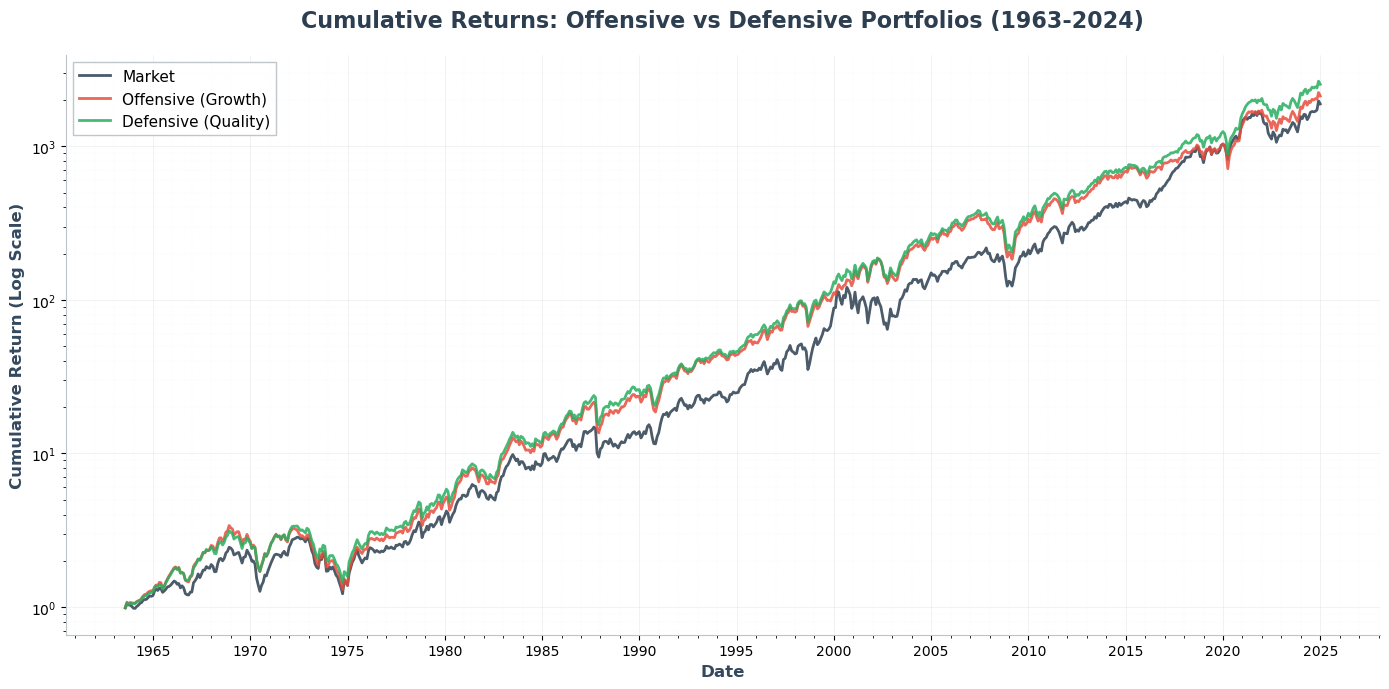


📊 Performance finale (1963-2024) :
   • Market     : $1,889 (1$ investi)
   • Offensive  : $2,129 (1$ investi)
   • Defensive  : $2,535 (1$ investi)

📈 CAGR (Compound Annual Growth Rate) :
   • Market     : 13.07% par an
   • Offensive  : 13.29% par an
   • Defensive  : 13.61% par an

✅ Graphique affiché : Cumulative Returns (Log Scale)


In [6]:
print("="*100)
print("📈 VISUALISATION : CUMULATIVE RETURNS")
print("="*100)

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ═══════════════════════════════════════════════════════════════════════════
# 1. CALCULER LES CUMULATIVE RETURNS
# ═══════════════════════════════════════════════════════════════════════════

cumret = (1 + df_output[['Market', 'Offensive', 'Defensive']]).cumprod()

# ═══════════════════════════════════════════════════════════════════════════
# 2. CRÉER LE GRAPHIQUE (STYLE SOBRE & PROFESSIONNEL)
# ═══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')

# Tracer les courbes
ax.plot(cumret.index, cumret['Market'], 
        color='#2C3E50', linewidth=2.0, label='Market', alpha=0.85)

ax.plot(cumret.index, cumret['Offensive'], 
        color='#E74C3C', linewidth=2.0, label='Offensive (Growth)', alpha=0.85)

ax.plot(cumret.index, cumret['Defensive'], 
        color='#27AE60', linewidth=2.0, label='Defensive (Quality)', alpha=0.85)

# ═══════════════════════════════════════════════════════════════════════════
# 3. STYLING AUSTÈRE & PROFESSIONNEL
# ═══════════════════════════════════════════════════════════════════════════

# Titre et labels
ax.set_title('Cumulative Returns: Offensive vs Defensive Portfolios (1963-2024)', 
             fontsize=16, fontweight='bold', color='#2C3E50', pad=20)
ax.set_xlabel('Date', fontsize=12, fontweight='600', color='#34495E')
ax.set_ylabel('Cumulative Return (Log Scale)', fontsize=12, fontweight='600', color='#34495E')

# Échelle logarithmique (meilleure pour long-terme)
ax.set_yscale('log')

# Grille sobre
ax.grid(True, which='major', linestyle='-', linewidth=0.5, color='#BDC3C7', alpha=0.3)
ax.grid(True, which='minor', linestyle=':', linewidth=0.3, color='#BDC3C7', alpha=0.2)

# Format des dates
ax.xaxis.set_major_locator(mdates.YearLocator(5))  # Tous les 5 ans
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.YearLocator(1))

# Rotation des labels
plt.xticks(rotation=0, ha='center')

# Légende sobre
ax.legend(loc='upper left', frameon=True, shadow=False, 
          framealpha=0.95, edgecolor='#BDC3C7',
          fontsize=11, fancybox=False)

# Suppression des bordures supérieure et droite
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#BDC3C7')
ax.spines['bottom'].set_color('#BDC3C7')

# Ajustement automatique
plt.tight_layout()

# Afficher
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# 4. STATS FINALES
# ═══════════════════════════════════════════════════════════════════════════

print(f"\n📊 Performance finale (1963-2024) :")
print(f"   • Market     : ${cumret['Market'].iloc[-1]:,.0f} (1$ investi)")
print(f"   • Offensive  : ${cumret['Offensive'].iloc[-1]:,.0f} (1$ investi)")
print(f"   • Defensive  : ${cumret['Defensive'].iloc[-1]:,.0f} (1$ investi)")

print(f"\n📈 CAGR (Compound Annual Growth Rate) :")
n_years = (df_output.index[-1] - df_output.index[0]).days / 365.25

cagr_market = (cumret['Market'].iloc[-1] ** (1/n_years)) - 1
cagr_off = (cumret['Offensive'].iloc[-1] ** (1/n_years)) - 1
cagr_def = (cumret['Defensive'].iloc[-1] ** (1/n_years)) - 1

print(f"   • Market     : {cagr_market*100:.2f}% par an")
print(f"   • Offensive  : {cagr_off*100:.2f}% par an")
print(f"   • Defensive  : {cagr_def*100:.2f}% par an")

print(f"\n✅ Graphique affiché : Cumulative Returns (Log Scale)")
print("="*100)

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# SAVE INDIVIDUAL RETURNS (50 SERIES) POUR ML FEATURES
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*100)
print("💾 SAVE INDIVIDUAL RETURNS (50 PORTFOLIOS)")
print("="*100)

# Construire dict des 50 séries (25 signaux × P10 + P1)
all_factors = {**OFFENSIVE_CONFIG, **DEFENSIVE_CONFIG}  # 25 signaux uniques
returns_50 = {}

for factor in set(all_factors.keys()):  # Évite doublons si même signal dans Off/Def
    signal_path = Path(f'data/portfolios/{factor}_signal.parquet')
    if signal_path.exists():
        signal_df = pd.read_parquet(signal_path).set_index('date')
        returns_50[f'{factor}_P10'] = signal_df['ret_high_ew']
        returns_50[f'{factor}_P1'] = signal_df['ret_low_ew']

df_returns_50 = pd.DataFrame(returns_50)

# Save
RETURNS_PATH = Path('data/ml_data/features/baseline/basket_1_individual_returns_50.parquet')
RETURNS_PATH.parent.mkdir(parents=True, exist_ok=True)
df_returns_50.to_parquet(RETURNS_PATH)

print(f"\n✅ INDIVIDUAL RETURNS SAVED :")
print(f"   📁 {RETURNS_PATH}")
print(f"   📦 Shape : {df_returns_50.shape} (50 portfolios)")
print("="*100)


💾 SAVE INDIVIDUAL RETURNS (50 PORTFOLIOS)



✅ INDIVIDUAL RETURNS SAVED :
   📁 data/ml_data/features/baseline/basket_1_individual_returns_50.parquet
   📦 Shape : (738, 50) (50 portfolios)


: 